## Imports and Data Prep

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from letterboxd_utils import clean_diary_data, remove_duplicate_movies, linear_regression_numpy, predict_linear_regression, accuracy_within_half_star
import requests
from bs4 import BeautifulSoup
import re
import unicodedata

In [30]:
def get_user_diary(username):
    """Creates a DataFrame of a user's Letterboxd diary given their username

    Args: 
        username (string): Letterboxd username

    Returns:
        df (DataFrame): DataFrame containing the information in a user's diary (movies, ratings, etc.)
    """

    # Finding the max page number
    url = f'https://letterboxd.com/{username}/films/diary/'
    html = requests.get(url).text
    soup = BeautifulSoup(html, 'html.parser')
    pagination = soup.find('div', class_='pagination')
    if pagination:
        max_page = int(pagination.find_all('li', class_='paginate-page')[-1].text) 
    else:
        max_page = 1

    all_data = [] 
    current_month = None 

    film_slug_list = []

    for i in range(1, max_page + 1):
        url = f'https://letterboxd.com/{username}/films/diary/page/{i}'
        html = requests.get(url).text
        soup = BeautifulSoup(html, 'html.parser')

        month_watched = soup.find_all(class_='td-calendar')
        day_watched = soup.find_all(class_='td-day diary-day center')
        films = soup.find_all('h3', class_='headline-3 prettify')
        released_dates = soup.find_all(class_='td-released center')
        ratings = soup.find_all('span', class_='rating')

        for j in range(len(films)): 
            if month_watched:
                current_month = month_watched[j].get_text(strip=True) if month_watched[j].get_text(strip=True) else current_month
            
            # getting film title for genre lookup
            film_title = films[j].get_text(strip=True)

            # Check for sequel number and year pattern (e.g. "Inside Out 2 2024")
            year_match = re.search(r'\s*(\d{4})\s*$', film_title)
            year = year_match.group(1) if year_match else None

            # Remove empty parentheses before creating slug
            film_title = re.sub(r'\s*\(\s*\)\s*', '', film_title)

            # Create base slug
            film_slug = '-'.join(re.sub(r'\s*:\s*', '-', film_title.lower()).split())

            # Convert non-ASCII characters to ASCII equivalents
            film_slug = unicodedata.normalize('NFKD', film_slug).encode('ascii', 'ignore').decode('ascii')
            film_slug = film_slug.replace('.', '') 

            # Clean up any remaining special characters except hyphens
            film_slug = re.sub(r'[^a-zA-Z0-9-]', '', film_slug)

            # Check for sequel number
            sequel_match = re.search(r'-(\d+)$', film_slug)

            # If we have both a sequel number and year, include both
            if sequel_match and year:
                base_slug = film_slug
                film_slug = f"{base_slug}-{year}"

            # Remove duplicate hyphens and clean up
            film_slug = re.sub(r'-+', '-', film_slug)
            film_slug = film_slug.strip('-')
                
            film_slug_list.append(film_slug)
            
            # fetching genres using the name of the film
            genre_url = f'https://letterboxd.com/film/{film_slug}/genres/'
            genre_html = requests.get(genre_url).text
            genre_soup = BeautifulSoup(genre_html, 'html.parser')
            genres = genre_soup.find('div', class_='text-sluglist capitalize')
            
            if genres:
                genre_list = [genre.text for genre in genres.find_all('a', class_='text-slug')]
                genres_str = ', '.join(genre_list) # joining the genres with commas
                
            else:
                genres_str = None
            
            data = {
                'Month': current_month,
                'Day': day_watched[j].get_text(strip=True) if j < len(day_watched) else None,
                'Film': film_title,
                'Released': released_dates[j].get_text(strip=True) if j < len(released_dates) else None,
                'Ratings': ratings[j].get_text(strip=True) if j < len(ratings) else None,
                'Genres': genres_str 
            }
            all_data.append(data)
            
    df = pd.DataFrame(all_data)
    return df, film_slug_list

In [32]:
username = 'kmgrimes'
df, film_slug_list = get_user_diary(username)
df = clean_diary_data(df)
df['Released'] = pd.to_numeric(df['Released'])
df['Day'] = pd.to_numeric(df['Day'])
df = remove_duplicate_movies(df)

unique_film_list = list(set(film_slug_list))
# print(unique_film_list)
print(film_slug_list)
print(len(unique_film_list))


['gladiator-ii', 'wicked', 'the-hangover', 'dont-move', 'piece-by-piece', 'carmen-jones', 'les-miserables', 'office-space', 'rio', 'scooby-doo-camp-scare', 'island-of-lost-souls', 'the-idea-of-you', 'sing-sing', 'rebel-ridge', 'beetlejuice-beetlejuice', 'the-holdovers', 'bottoms', 'dicks-the-musical', 'the-accountant', 'didi', 'it-ends-with-us', 'minions-the-rise-of-gru', 'the-bad-guys', 'princess-mononoke', 'porco-rosso', 'deadpool-wolverine', 'best-in-show', 'maxxxine', 'now-you-see-me', 'twisters', 'red-white-royal-blue', 'kinds-of-kindness', 'a-quiet-place-day-one', 'flushed-away', 'five-nights-at-freddys', 'jaws', 'everybody-wants-some', 'pearl', 'inside-out-2', 'holes', 'am-i-ok', 'the-kissing-booth-2', 'anatomy-of-a-fall', 'the-devil-wears-prada', 'eighth-grade', 'kill-bill-vol-1', 'anyone-but-you', 'the-greatest-night-in-pop', 'but-im-a-cheerleader', 'small-town-gay-bar', 'dune-part-two', 'wonka', 'dune', 'all-of-us-strangers', 'the-meg', 'notting-hill', 'poor-things', 'mamma-m

In [5]:
df.head()

,Month,Day,Film,Released,Ratings,Genres,Year
0,11,25,Gladiator II,2024,3.5,"Action, Adventure",2024
1,11,21,Wicked,2024,4.0,Thriller,2024
2,11,20,The Hangover,2009,4.0,Comedy,2024
3,11,18,Don't Move,2024,2.0,"Drama, Romance",2024
4,10,23,Piece By Piece,2024,3.0,Documentary,2024


In [6]:
print(df)

     Month  Day                   Film  Released  Ratings  \
0       11   25           Gladiator II      2024      3.5   
1       11   21                 Wicked      2024      4.0   
2       11   20           The Hangover      2009      4.0   
3       11   18             Don't Move      2024      2.0   
4       10   23         Piece By Piece      2024      3.0   
..     ...  ...                    ...       ...      ...   
177      2   12  But I'm a Cheerleader      1999      4.0   
178      2    6                Maurice      1987      3.0   
179     10   30                  Ponyo      2008      5.0   
180     10   26            Open Season      2006      3.0   
181      1   19         It Chapter Two      2019      5.0   

                                   Genres  Year  
0                       Action, Adventure  2024  
1                                Thriller  2024  
2                                  Comedy  2024  
3                          Drama, Romance  2024  
4                

## One-Hot Genres Vector With Release Date to Predict Rating

In [4]:
# Handle missing genres and create a list of unique genres
df['Genres'] = df['Genres'].fillna('None')

all_genres = []
for genres in df['Genres']:
    for genre in genres.split(', '):
        if genre not in all_genres:
            all_genres.append(genre)
unique_genres = sorted(list(set(all_genres)))
num_genres = len(unique_genres)
print(all_genres)

['Action', 'Adventure', 'Thriller', 'Comedy', 'Drama', 'Romance', 'Documentary', 'History', 'Crime', 'Mystery', 'Family', 'Animation', 'Horror', 'Science Fiction', 'Fantasy', 'None', 'Music', 'TV Movie', 'Western']


In [5]:
# transferring to numpy arrays instead of pandas dfs
release_year = df['Released'].values.reshape(-1, 1)  # to a column vector
genre_matrix = np.zeros((len(df), num_genres)) # intialize a matrix of zeros

In [6]:
# One-Hot Encoding for Genres (Feature Matrix)
for i, genres in enumerate(df['Genres']):
    for genre in genres.split(', '):
        j = unique_genres.index(genre)
        genre_matrix[i, j] = 1

In [7]:
# Combine Release Year and Genre Matrix
X = np.concatenate((release_year, genre_matrix), axis=1) #concatenate the release year and the genres together
y = df['Ratings'].values

In [8]:
print("Features Matrix (X) shape:", X.shape)
print("Target Variable (y) shape:", y.shape)
print("\nFeatures (X):")
print(X[2:5])
print("\nTarget Variable (y):")
print(y)

Features Matrix (X) shape: (182, 20)
Target Variable (y) shape: (182,)

Features (X):
[[2.009e+03 0.000e+00 0.000e+00 0.000e+00 1.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [2.024e+03 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  1.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 1.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [2.024e+03 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 1.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00]]

Target Variable (y):
[3.5 4.  4.  2.  3.  4.  4.5 3.  3.  4.  0.  3.  5.  1.5 3.5 4.  5.  2.5
 3.  4.  2.  4.  1.5 4.  5.  3.  3.5 3.  3.5 4.  3.  2.5 4.  2.5 4.5 3.
 2.5 4.  3.5 4.5 2.5 5.  4.  3.5 3.5 3.  2.  3.5 4.  0.  4.5 4.5 4.  4.
 3.  3.5 4.  4.5 4.  4.5 4.  4.  4.5 3.5 1.5 5.  2.5 

#### Splitting the data 60-20-20, train-validation-test

In [9]:
indices = np.arange(X.shape[0]) #create an array of numbers representing the index of the row
np.random.seed(42) #setting a random seed for reproducibility
np.random.shuffle(indices) #shuffles the indices in place

In [10]:
train_cutoff = int(0.6 * len(indices)) #gets the first 60% of the indices
val_cutoff = int(0.8 * len(indices)) #gets the next 20% of the indices after the training cutoff

train_indices = indices[:train_cutoff] #indices for the training set
val_indices = indices[train_cutoff:val_cutoff] #indices for the validation set
test_indices = indices[val_cutoff:] #indices for the test set

In [11]:
X_train, y_train = X[train_indices], y[train_indices] #training set
X_val, y_val = X[val_indices], y[val_indices] #validation set
X_test, y_test = X[test_indices], y[test_indices] #test set

### linear regression defined in the utils file, training portion

In [12]:
# training
weights, intercept = linear_regression_numpy(X_train, y_train)

In [13]:
# predictions on validation and test sets
y_val_pred_np = predict_linear_regression(X_val, weights, intercept)
y_test_pred_np = predict_linear_regression(X_test, weights, intercept)

In [14]:
mse_val_np = mean_squared_error(y_val, y_val_pred_np)
r2_val_np = r2_score(y_val, y_val_pred_np)
mse_test_np = mean_squared_error(y_test, y_test_pred_np)
r2_test_np = r2_score(y_test, y_test_pred_np)

print(f"NumPy - Validation MSE: {mse_val_np:.2f}, R-squared: {r2_val_np:.2f}")
print(f"NumPy - Test MSE: {mse_test_np:.2f}, R-squared: {r2_test_np:.2f}")

NumPy - Validation MSE: 1.58, R-squared: -0.16
NumPy - Test MSE: 0.93, R-squared: -0.25


In [15]:
accuracy_val = accuracy_within_half_star(y_val, y_val_pred_np)
accuracy_test = accuracy_within_half_star(y_test, y_test_pred_np)
print(f"NumPy - Validation Accuracy (within 0.5 stars): {accuracy_val:.2f}")
print(f"NumPy - Test Accuracy (within 0.5 stars): {accuracy_test:.2f}")

NumPy - Validation Accuracy (within 0.5 stars): 0.28
NumPy - Test Accuracy (within 0.5 stars): 0.35


## Testing Assumptions

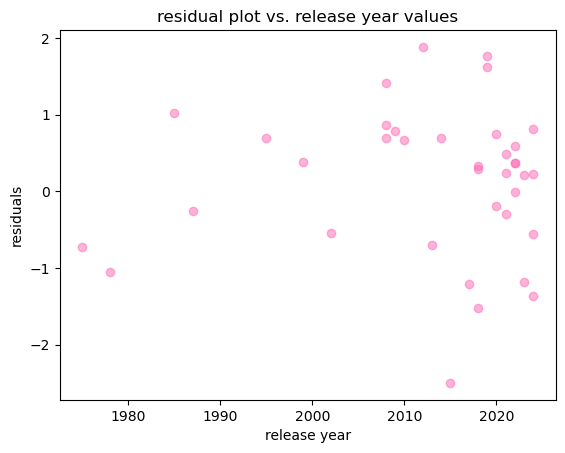

In [16]:
# independence assumption
resids =  y_test - y_test_pred_np
X_test_0 = X_test[:, 0]

plt.scatter(X_test_0, resids, alpha=0.5, color="hotpink")
plt.xlabel("release year")
plt.ylabel("residuals")
plt.title("residual plot vs. release year values")
plt.show()

This plot is close to being centered around zero, which is good. The variance though is cause for concern, it has unequal distribution. This raises issues with the independence assumption being met. 

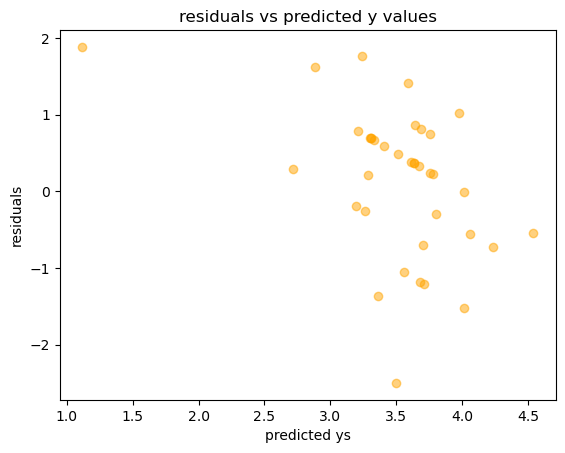

In [17]:
# constant variance
plt.scatter(y_test_pred_np, resids, alpha=.5, color="orange")
plt.xlabel('predicted ys')
plt.ylabel('residuals')
plt.title('residuals vs predicted y values')
plt.show()

This plot reveals two things of importance. First, this appears to be centered around zero which is good for meeting the constant variance assumption. The variance though, is not constant which is not good. Second, the outlier here reveals that our algorithm is not cutting off at the correct place, as the maximum rating should be 5.0. It is interesting that the model did not predict any scores of 2.5 or lower. 

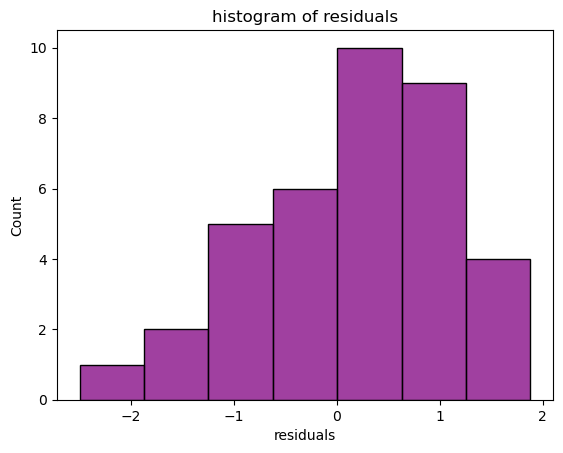

In [18]:
# histogram of residuals
sns.histplot(resids, kde=False, color="purple")
plt.xlabel("residuals")
plt.title("histogram of residuals")
plt.show()

The histogram does not follow the normal curve. This is not good, and indicates that the normality assumption is not met. 

Overall, our results are pretty bad as the baseline of random guessing with + or - 0.5 stars is 30% accuracy. The above plots indicate that there are significant issues with the data meeting the linear regression assumptions. Going forward we probably should try a more complex model with the limited data we have as basic linear regression isn't producing a great result here. Further, we aim in the next phase to implement an additional API that will allow us to scrape more movie features and build a more comprehensive dataset. 

Issues we have identified: 
- Limited features: Genre and release date are likely insufficient predictors of movie ratings. We wanted to test this out first with our preliminary model to see the mathematical proof that more features are necessary for a stronger model. The poor accuracy was predicted by our group, and now we have strong evidence to support additional feature finding. 

- Small dataset: Since the model runs on a specific user's watched and rated movies, it is limited by a small dataset. Here, we pull from a group member's Letterboxd which currently has 170 movies logged. After splitting this dataset into training sets, testing sets, and validation sets, we are left with kind of a small amount of movies to test the linear regression on. 

Next Steps 
- Feature finding and engineering: We will implement an additional API to gather features from the watched movies. Some features we aim to gather are IMDb ratings, budget, cast, director, and profit. We need a larger, more diverse dataset (Kyra, the group member with the letterboxd account, will keep watching and rating movies!). It would also be interesting to consider derived features (ex. a popularity score based on popular rating and profit). We also hope to try more complex machine learning models such as KNN which may provide better accuracy results. 

maybe incorporating imdb ratings and budget could help and a more complex model, here is what an AI has to say about the results:

Yes, for a proof of concept, even a "terrible" result like this is perfectly fine, especially given the limitations you've identified. The purpose of a proof of concept is not necessarily to achieve stellar performance but to demonstrate that:

Your pipeline works: You've shown you can collect, clean, process, and feed data into a model.
You can implement and evaluate a model: You've demonstrated your understanding of linear regression (and in a way that fulfills the NumPy requirement, which is great).
You can analyze results and identify limitations/next steps: This is where your reflections on the poor performance and ideas for improvement are crucial.

Focus your discussion on why the results are bad and what you can do to improve them. Here are some key points to emphasize:

Limited Features: As you mentioned, genre and release date are likely insufficient predictors of movie ratings. User preferences are complex and depend on many factors (plot, actors, director, mood, etc.). Explicitly stating this limitation demonstrates your understanding.

Small Dataset: 170 movies, while a good start, are a relatively small dataset for machine learning, especially with many genres. Models need sufficient data to learn complex patterns. Highlight this as a key constraint.

Multicollinearity: Discuss how the one-hot encoded genre features likely introduced multicollinearity, which you addressed with regularization. This shows you understand potential issues with this type of encoding.

Baseline Comparison: Calculate the baseline accuracy (within ±0.5 stars) for predicting the mean rating. If your model's accuracy is even slightly better, you can highlight that as a small win. If not, acknowledge that the model doesn't outperform the simplest baseline and explain why.

Future Improvements: This is the most important part. Clearly outline how you would improve the model:

More Data: Emphasize the need for a larger, more diverse dataset.

Rich Features: Discuss incorporating IMDb ratings, budget, cast/crew information, user reviews, etc. Explain how these could be obtained and preprocessed.

Feature Engineering: Consider interaction terms (e.g., genre x release year), or creating derived features (e.g., a "popularity" score based on various factors).

More Advanced Models: Mention K-Nearest Neighbors, decision trees, or other suitable algorithms as potential next steps. Explain why these might be better suited to this task than linear regression.

In [16]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
pd.set_option('display.max_colwidth', None)

import time

In [19]:
# Lin's proposal 
# get the top-250 movies data frm Flickfocus
url = 'https://flickfocus.com/movies/'
url_list = []
for movie in unique_film_list:
    url_list.append(url + movie)

response_list = []
for url in url_list:
    response_list.append(requests.get(url))

soup_list = []
for response in response_list:
    soup = BeautifulSoup(response.text, "html.parser")
    soup_list.append(soup)


print(soup_list)


169


In [ ]:
print(url_list)
print(len(url_list))


['https://flickfocus.com/movies/hustle', 'https://flickfocus.com/movies/renaissance-a-film-by-beyonce', 'https://flickfocus.com/movies/beetlejuice-beetlejuice', 'https://flickfocus.com/movies/the-greatest-night-in-pop', 'https://flickfocus.com/movies/now-you-see-me', 'https://flickfocus.com/movies/all-of-us-strangers', 'https://flickfocus.com/movies/teenage-mutant-ninja-turtles-mutant-mayhem', 'https://flickfocus.com/movies/the-princess-and-the-frog', 'https://flickfocus.com/movies/superbad', 'https://flickfocus.com/movies/bodies-bodies-bodies', 'https://flickfocus.com/movies/aftersun', 'https://flickfocus.com/movies/se7en', 'https://flickfocus.com/movies/zatoichis-cane-sword', 'https://flickfocus.com/movies/lady-chatterleys-lover', 'https://flickfocus.com/movies/minions-the-rise-of-gru', 'https://flickfocus.com/movies/a-quiet-place-day-one', 'https://flickfocus.com/movies/maxxxine', 'https://flickfocus.com/movies/american-beauty', 'https://flickfocus.com/movies/it-ends-with-us', 'http

In [116]:
#a function to extract the data (using second API)
def extract_user_movies(soup_list):
    """Extract movie data from FlickFocus movie pages.
    
    Args:
        soup (BeautifulSoup): Parsed HTML response from FlickFocus containing
                            'Title','Link', 'IMDb Rating', 'Release Date', 
                            'Language','Budget', 'Revenue', 'Production Companies','Countries'
        
    Returns:
        DataFrame: DataFrame containing movie information.
    """
    #initialize lists
    movie_list = []
    link_list = []
    rating_list = []
    release_date_list = []
    language_list = []
    budget_list = []
    revenue_list = []
    companies_list = []
    countries_list = []
    
    for soup in soup_list:
        #extract movie titles and links from the main page
        for movie in soup.find_all('a', class_='block hover:opacity-75'):
            title = movie.get('title', 'No Title')
            link = movie.get('href', 'No Link')
            
            #go to the individual movie page for more info
            movie_page = requests.get(link)
            movie_soup = BeautifulSoup(movie_page.content, 'html.parser')
            
            #extract IMDb rating
            rating = None
            rating_div = movie_soup.find('div', class_='ml-1 font-bold text-xs lg:text-sm')
            if rating_div:
                rating = rating_div.text.strip()
            
            #extract only the in theatres release date
            in_theatres_release_date = None
            theatre_release_div = movie_soup.find('div', string='In Theatres')
            if theatre_release_div:
                date_div = theatre_release_div.find_next_sibling('div')
                if date_div:
                    in_theatres_release_date = date_div.text.strip()
            
            #extract language
            language = None
            language_div = movie_soup.find('a', class_='text-blue-500 hover:underline')
            if language_div:
                language = language_div.text.strip()
            
            #extract budget
            budget_value = None
            budget_div = movie_soup.find('div', string='Budget')
            if budget_div:
                budget_amount_div = budget_div.find_next_sibling('div')
                if budget_amount_div:
                    budget_text = budget_amount_div.text.strip()
                    if "$" in budget_text:
                        budget_value = float(budget_text.replace("$", "").replace(",", ""))
            
            #extract revenue
            revenue_value = None
            revenue_div = movie_soup.find('div', string='Revenue')
            if revenue_div:
                revenue_amount_div = revenue_div.find_next_sibling('div')
                if revenue_amount_div:
                    revenue_text = revenue_amount_div.text.strip()
                    if "$" in revenue_text:
                        revenue_value = float(revenue_text.replace("$", "").replace(",", ""))
            
            #extract production companies
            companies = []
            companies_div = movie_soup.find('div', string='Companies')
            if companies_div:
                companies_links_div = companies_div.find_next_sibling('div')
                if companies_links_div:
                    for company in companies_links_div.find_all('a'):
                        companies.append(company.text.strip())
            
            #extract countries
            countries = []
            countries_div = movie_soup.find('div', string='Countries')
            if countries_div:
                countries_links_div = countries_div.find_next_sibling('div')
                if countries_links_div:
                    for country in countries_links_div.find_all('a'):
                        countries.append(country.text.strip())
            
            #append extracted data to lists
            movie_list.append(title)
            link_list.append(link)
            rating_list.append(float(rating) if rating else None)#check if there is rating in numeric value 
            release_date_list.append(in_theatres_release_date)
            language_list.append(language)
            budget_list.append(budget_value)
            revenue_list.append(revenue_value)
            
            #use join so it more fits to the dataframe 
            companies_list.append(', '.join(companies) if companies else None)#check if there is company
            countries_list.append(', '.join(countries) if countries else None)#check if there is country
        
            time.sleep(1)
    #store the extracted data into a dictionary and convert to a DataFrame
    movie_dict = {
        'Title': movie_list,
        'Link': link_list,
        'IMDb Rating': rating_list,
        'In Theatres Release Date': release_date_list,
        'Language': language_list,
        'Budget': budget_list,
        'Revenue': revenue_list,
        'Production Companies': companies_list,
        'Countries': countries_list
    }
    
    df_movies = pd.DataFrame.from_dict(movie_dict)
    
    return df_movies

In [117]:
movie_data = extract_user_movies(soup_list)
movie_data

,Title,Link,IMDb Rating,In Theatres Release Date,Language,Budget,Revenue,Production Companies,Countries
0,Beetlejuice Beetlejuice,https://flickfocus.com/movies/beetlejuice-beetlejuice,7.1,"Sep 6, 2024 (PG-13)",English,100000000.0,451072781.0,"Plan B Entertainment, Warner Bros. Pictures, Geffen Pictures, Tim Burton Productions, Domain Entertainment, Tommy Harper Productions",United States
1,Beetlejuice,https://flickfocus.com/movies/beetlejuice,7.5,"Mar 30, 1988 (PG)",English,15000000.0,84554197.0,"Warner Bros. Pictures, Geffen Pictures",United States
2,Now You See Me 3,https://flickfocus.com/movies/now-you-see-me-3,NaN,"Nov 14, 2025",English,NaN,NaN,"Lionsgate, Secret Hideout",United States
3,Now You See Me 2,https://flickfocus.com/movies/now-you-see-me-2,6.4,"Jun 10, 2016 (PG-13)",English,120000000.0,334900000.0,"Summit Entertainment, Lionsgate, K/O Paper Products, TIK Films","Hong Kong, United States"
4,Now You See Me,https://flickfocus.com/movies/now-you-see-me,7.2,"May 31, 2013 (PG-13)",English,75000000.0,351700000.0,"Summit Entertainment, K/O Paper Products, SOIXAN7E QUIN5E, See Me Louisiana","France, United States"
...,...,...,...,...,...,...,...,...,...
65,Open Season,https://flickfocus.com/movies/open-season,6.1,"Sep 29, 2006 (PG)",English,85000000.0,197300000.0,"Columbia Pictures, Sony Pictures Animation",United States
66,Kung Fu Panda 4,https://flickfocus.com/movies/kung-fu-panda-4,6.3,"Mar 8, 2024 (PG)",English,80000000.0,548040835.0,DreamWorks Animation,United States
67,Kung Fu Panda 3,https://flickfocus.com/movies/kung-fu-panda-3,7.1,"Jan 29, 2016 (PG)",English,145000000.0,521170825.0,"DreamWorks Animation, China Film Group Corporation, Oriental DreamWorks, Zhong Ming You Ying Film","China, United States"
68,Kung Fu Panda 2,https://flickfocus.com/movies/kung-fu-panda-2,7.3,"May 26, 2011 (PG)",English,150000000.0,665692281.0,DreamWorks Animation,United States


In [118]:
imdb_ratings = movie_data['IMDb Rating']
print(imdb_ratings)

0     7.1
1     7.5
2     NaN
3     6.4
4     7.2
     ... 
65    6.1
66    6.3
67    7.1
68    7.3
69    7.6
Name: IMDb Rating, Length: 70, dtype: float64
